![FaMAF-UNC](https://drive.google.com/uc?export=download&id=1k4tzcXOoq6TrkDEW_Ox8o4Y4pAHzKHb7
)
> Docentes: **Damián Fernández** y **Leandro Milne**
>> Teórico del 21-05-2021


# Campos vectoriales

## Integrales sobre curvas

Cuando estudiamos curvas, vimos que la longitud de una trayectoria continuamente diferenciable a trozos $\gamma:[a,b] \to \mathbb{R}^n$ se define como
$$
    \ell(\gamma) = \int_a^b \|\gamma'(t)\| dt
$$
Ralizando un paralelo con lo visto con integrales múltiples, la medida unidimensional de la curva definida por $\gamma$ viene de integrar la función constante igual a uno, o sea
$$
    \int_a^b 1 \|\gamma'(t)\| dt,
$$
dejando claro que, al igual que con las integrales múltiples, podemos tomar una función distinta de uno.




>**Definición**
>
> Si $f:\mathbb{R}^n \to \mathbb{R}$ está definida sobre la trayectoria continuamente diferenciable a trozos $\gamma:[a,b] \to \mathbb{R}^n$, la **integral de $f$ sobre $\gamma$** es
$$
  \int_a^b f(\gamma(t)) \|\gamma'(t) \| dt.
$$



Note que si consideramos la función de longitud de arco $\zeta:[a,b] \to [0,\ell(\gamma)]$, su inversa $\tau$ y la reparametrización por longitud de arco $\sigma(s) = \gamma(\tau(s))$, tenemos que
\begin{align*}
    \int_0^{\ell(\gamma)} f(\sigma(s)) ds &= \int_{\zeta(a)}^{\zeta(b)} f(\sigma(s)) ds \\
                &= \int_a^b f(\sigma(\zeta(t))) \zeta'(t) dt \\
                &= \int_a^b f(\gamma(t))\|\gamma'(t)\| dt,
\end{align*}
donde usamos que $\zeta'(t) = \|\gamma'(t)\|$ y $\tau(\zeta(t))=t$. Por ello, una notación práctica para la integral de $f$ sobre $\gamma$ es
$$
    \int_\gamma f(x) ds.
$$



Para poder interpretar esta integral, suponga que $f:\mathbb{R}^2 \to \mathbb{R}$ es no negativa y $\gamma:[a,b] \to \mathbb{R}^2$, luego
$$
    \int_\gamma f(x) ds = \int_a^b f(\gamma_1(t),\gamma_2(t)) \sqrt{\gamma_1'(t)^2 + \gamma_2'(t)^2} dt,
$$
es el área de una valla cuya base en el plano es dada por la curva que define $\gamma$ y cuya altura es dada por los valores de la función $f$.

#### Ejemplo

Suponga que se desea pintar un muro perimetral y se desea conocer el área total a pintar.



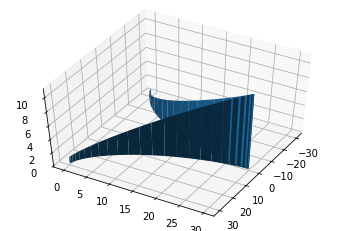

In [ ]:
#@title Área del muro { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

ax = plt.axes(projection='3d')
th = np.linspace(0, np.pi, 100)
x1 = np.outer(np.ones((2,1)), 30*np.cos(th)**3)
x2 = np.outer(np.ones((2,1)), 30*np.sin(th)**3)
x3 = np.outer(np.array([0,1]), 1 + 10*np.sin(th)**3)
ax.plot_surface(x1, x2, x3);
ax.view_init(50,30)
#plt.savefig('ejm_areamuro.pdf')

La forma de la base del muro se asemeja a la curva dada por $\gamma:[0,\pi] \to \mathbb{R}^2$ y la altura del muro se aproxima a la dada por $f:\mathbb{R}^2 \to \mathbb{R}$ tales que
$$
    \gamma(t) = \bigl( 30 \cos^3(t), 30 \operatorname{sen}^3(t)\bigr), \qquad
    f(x) = 1 + \frac{x_2}{3}.
$$
Por lo tanto, el área buscada es la dada por la integral de $f$ sobre $\gamma$.

Como $\gamma'(t) = \bigl( -90 \cos^2(t)\operatorname{sen}(t) , 90 \operatorname{sen}^2(t) \cos(t)\bigr)$, entonces $\|\gamma'(t)\| = 90 |\cos(t)| \operatorname{sen}(t)$. Tomando $\theta = \pi -t$ para $t\in [\pi/2,\pi]$,
\begin{align*}
    \int_\gamma f(x) ds
    &= 2 \int_0^{\pi/2} \left( 1 + \frac{30 \operatorname{sen}^3(t)}{3}\right) 90 \cos(t) \operatorname{sen}(t) dt \\
    &= 180 \int_0^{\pi/2} (\operatorname{sen}(t) + 10 \operatorname{sen}^4(t) ) \cos(t) dt \\
    &= 180 \left[ {\textstyle \frac{1}{2}} \operatorname{sen}^2(t) + 2 \operatorname{sen}^5(t)\right]_0^{\pi/2}\\
    &= 180\left({\textstyle \frac{1}{2}} + 2  \right) = 450.
\end{align*}

---


Suponga ahora que se tiene un campo $F:\mathbb{R}^3 \to \mathbb{R}^3$ que representa una fuerza que está actuando sobre una partícula en $\mathbb{R}^3$. Si esta partícula se mueve en línea recta, dada por la trayectoria $t \mapsto x + t v$, y la fuerza es constante, entonces el trabajo que realiza $F$ sobre la partícula es igual a la fuerza por el desplazamiento en la dirección de la fuerza. Matemáticamente, el trabajo sería $\langle F(x), v \rangle$. Note que este producto interno también representa la componente de $F(x)$ a lo largo de $v$, si $v$ es unitaria.

Cuando la partícula se mueve a lo largo de una trayectoria dada por $\gamma:[a,b] \to \mathbb{R}^3$, la dirección de desplazamiento en cada punto viene dada por el vector tangente a la curva, obteniendo que en cada punto $x=\gamma(t)$ el trabajo es
$$
    \langle F(x) , T(t) \rangle = \left\langle F(\gamma(t)), \frac{\gamma'(t)}{\|\gamma'(t)\|} \right\rangle.
$$
Por lo tanto, al sumar todos los aportes sobre la curva obtenemos que el trabajo realizado es
$$
 \int_a^b \left\langle F(\gamma(t)), \frac{\gamma'(t)}{\|\gamma'(t)\|} \right\rangle \|\gamma'(t)\| dt = \int_a^b \langle F(\gamma(t)), \gamma'(t) \rangle dt.
$$




> **Definición**
>
> Si $F:\mathbb{R}^n \to \mathbb{R}^n$ está definida sobre la trayectoria continuamente diferenciable a trozos $\gamma:[a,b] \to \mathbb{R}^n$, la **integral de línea de $F$** a lo largo de $\gamma$ es
$$
 \int_a^b \langle F(\gamma(t)), \gamma'(t) \rangle dt.
$$



De manera análoga a lo visto para funciones a valores escalares, si consideramos la reparametrización por longitud de arco $\sigma(s) = \gamma(\tau(s))$ obtenemos
$$
    \int_0^{\ell(\gamma)} \langle F(\sigma(s)), \sigma'(s) \rangle ds = \int_a^b \langle F(\gamma(t)), \gamma'(t) \rangle dt.
$$
Con esto, una notación práctica para la integral de línea de $F$ a lo largo de $\gamma$ es
$$
    \int_\gamma F(x) ds, \quad \int_\gamma F_1(x)dx_1 + \ldots + F_n(x) dx_n , \quad \int_\gamma \langle F(x) , dx \rangle , \quad \int_\gamma F(x) \cdot ds,
$$
donde esta última tiene sentido cuando el producto interno $\langle x, y \rangle$ se denota por $x \cdot y$.



#### Ejemplo

Sea $F:\mathbb{R}^3 \to \mathbb{R}^3$ tal que $F(x) = x$ y $\gamma:[0, 2\pi] \to \mathbb{R}^3$ tal que $\gamma(t) =\bigl(\operatorname{sen}(t), \cos(t), t \bigr)$. Entonces
\begin{align*}
  \int_\gamma F(x) ds &= \int_0^{2\pi} \langle \gamma(t), \gamma'(t) \rangle dt \\
  &= \int_0^{2\pi} \bigl( \operatorname{sen}(t) \cos(t) - \cos(t)\operatorname{sen}(t) + t  \bigr) dt \\
  &=\int_0^{2\pi} t dt = 2\pi^2
\end{align*}

---

Cuando uno tiene una reparametrización $\beta:[c,d] \to \mathbb{R}^n$ de una trayectoria $\gamma:[a,b] \to \mathbb{R}^n$, entonces
$$
    \beta(s) = \gamma(\xi(s)),
$$
donde $\xi:[c,d] \to [a,b]$ es biyectiva. En el caso que
$$
    \beta(c) = \gamma(a), \qquad \beta(d) = \gamma(b),
$$
diremos que la reparametrización preserva la orientación y si
$$
    \beta(c) = \gamma(b), \qquad \beta(d) = \gamma(a),
$$
diremos que la reparametrización invierte la orientación.

Por ejemplo, la trayectoria $\beta:[a,b] \to \mathbb{R}^n$ tal que $\beta(t) = \gamma(a+b-t)$, es una reparametrización que invierte la orientación de $\gamma$ y suele ser llamada la trayectoria opuesta a $\gamma$.



> **Teorema**
>
> Sea $F:\mathbb{R}^n \to \mathbb{R}^n$ definida sobre $\gamma:[a,b] \to \mathbb{R}^n$ y sea $\beta:[c,d] \to \mathbb{R}^n$ una reparametrización de $\gamma$. Si $\beta$ preserva la orientación, entonces
 $$
 \int_\beta F(x) ds = \int_\gamma F(x) ds,
 $$
 y si $\beta$ invierte la orientación, entonces
 $$
 \int_\beta F(x) ds = - \int_\gamma F(x) ds,
 $$


**Demostración**

Como $\beta(u) = \gamma(\xi(u))$, entonces $\beta'(u) = \gamma'(\xi(u)) \xi'(u)$. Luego
\begin{align*}
    \int_\beta F(x) ds &= \int_c^d \langle F(\beta(u)), \beta'(u) \rangle du \\
    &= \int_c^d \langle F(\gamma(\xi(u)), \gamma'(\xi(u)) \rangle \xi'(u) du \\
    &= \int_{\xi(c)}^{\xi(d)} \langle F(\gamma(t)), \gamma'(t) \rangle dt,
\end{align*}
donde usamos la sustitución $t = \xi(u)$. Por lo tanto, si $\beta$ preserva orientación
$$
\int_\beta F(x) ds = \int_{a}^{b} \langle F(\gamma(t)), \gamma'(t) \rangle dt
                    = \int_\gamma F(x) ds,
$$
y si $\beta$ invierte orientación
$$
\int_\beta F(x) ds = \int_{b}^{a} \langle F(\gamma(t)), \gamma'(t) \rangle dt
                    = - \int_\gamma F(x) ds. \quad \spadesuit
$$




Este cambio de signo al invertir la orientación de la curva no ocurre cuando se trabaja con funciones a valores reales.

> **Teorema**
>
> Sea $f:\mathbb{R}^n \to \mathbb{R}$ definida sobre $\gamma:[a,b] \to \mathbb{R}^n$ y sea $\beta:[c,d] \to \mathbb{R}^n$ una reparametrización de $\gamma$. Entonces
 $$
 \int_\beta f(x) ds = \int_\gamma f(x) ds.
 $$


**Demostración**

Sea $\beta(u) = \gamma(\xi(u))$.
Note que si $\xi:[c,d] \to [a,b]$ es biyectiva y $\xi(c) = a, \xi(d) = b$ entonces $\xi$ es una función no decreciente y por lo tanto $\xi'(u)\geq 0$. Si $\xi(c) = b, \xi(d) = a$ entonces $\xi$ es una función no creciente y por lo tanto $\xi'(u)\leq 0$.
Como $\beta'(u) = \gamma'(\xi(u)) \xi'(u)$, entonces
\begin{align*}
    \int_\beta f(x) ds &= \int_c^d f(\beta(u)) \|\beta'(u)\| du \\
    &= \int_c^d f(\gamma(\xi(u)) \|\gamma'(\xi(u))\| |\xi'(u)| du \\
    &= \int_{a}^{b} f(\gamma(t)) \|\gamma'(t)\| dt\\
    &= \int_\gamma f(x) ds,
\end{align*}
donde usamos la sustitución $t = \xi(u)$ y el hecho que $|\xi'(u)| = \xi'(u)$ cuando se preserva orientación y $|\xi'(u)| = -\xi'(u)$ cuando se invierte orientación. $\spadesuit$



Cuando el campo vectorial tiene cierta estructura se pueden obtener resultados particulares.

>**Definición**
>
> Diremos que $F:\mathbb{R}^n \to \mathbb{R}^n$ es un **campo vectorial gradiente** si $F(x) = \nabla f (x)$ para alguna función $f:\mathbb{R}^n \to \mathbb{R}$.




Para campos gradientes tenemos lo siguiente.

> **Proposición**
>
> Sea $f:\mathbb{R}^n \to \mathbb{R}$ definida y diferenciable sobre la trayectoria continuamente diferenciable a trozos $\gamma:[a,b] \to \mathbb{R}^n$. Entonces
$$
    \int_\gamma \nabla f(x) ds = f(\gamma(b)) - f(\gamma(a)).
$$

**Demostración**

Sea $g(t) = f(\gamma(t))$, luego $g'(t) = \langle \nabla f(\gamma(t)) , \gamma'(t) \rangle$ y
\begin{align*}
    \int_\gamma \nabla f(x) ds &= \int_a^b \langle \nabla f(\gamma(t)), \gamma'(t) \rangle dt\\
        &= \int_a^b g'(t) dt = g(b) - g(a) \\
        &= f(\gamma(b))- f(\gamma(a)). \quad \spadesuit
\end{align*}



Cuando la curva en donde se está integrando tiene cierta estructura, también se obtienen resultados particulares.

> **Definición**
>
> Sea $\mathcal{C}$ la imagen de una trayectoria $\gamma:[a,b] \to \mathbb{R}^n$ continuamente diferenciable a trozos.
>Diremos que $\mathcal{C}$ es una **curva simple** si $\gamma$ es inyectiva (salvo en sus extremos) y diremos que $\mathcal{C}$ es una **curva cerrada** si $\gamma(a) = \gamma(b)$.

Una curva simple $\mathcal{C}$ puede tener solamente dos orientaciones dependiendo en cuál extremos se comience. Cuando se le asocia una orientación diremos que $\mathcal{C}$ es una **curva simple orientada**. En este caso, denotaremos por $\mathcal{C}^-$ a la curva con la otra orientación.


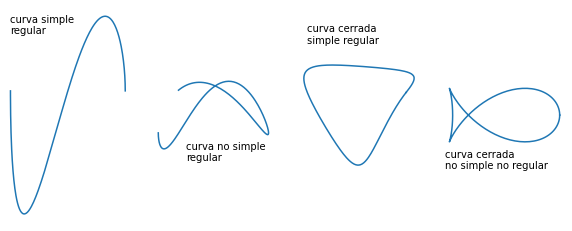

In [ ]:
#@title Curvas { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 1, 200)
fig, axs = plt.subplots(1,4,figsize=(10,4))
axs[0].plot(np.cos(np.pi*t), np.sin(2*np.pi*t)*np.exp(t))
axs[0].text(-1,1,'curva simple \nregular')
axs[0].axis('equal')
axs[0].axis('off')
axs[1].plot(np.cos(np.pi*np.exp(t)), np.cos(2*np.pi*t)*np.sin(np.pi*np.exp(t)))
axs[1].text(-0.5,-0.5,'curva no simple \nregular')
axs[1].axis('equal')
axs[1].axis('off')
axs[2].plot((2+20*t*(t-0.5)*(t-1))*np.cos(2*np.pi*t), (2-20*t*(t-0.5)*(t-1))*np.sin(2*np.pi*t))
axs[2].text(-2,2,'curva cerrada \nsimple regular')
axs[2].axis('equal')
axs[2].axis('off')
axs[3].plot(np.cos(2*np.pi*t)-np.sin(2*np.pi*t)**2/np.sqrt(2), np.cos(2*np.pi*t)*np.sin(2*np.pi*t))
axs[3].text(-1.15,-1,'curva cerrada \nno simple no regular')
axs[3].axis('equal')
axs[3].axis('off');
plt.savefig('curvassimples.pdf')




Cuando $\mathcal{C}$ es una curva simple orientada, podemos definir sin ambigüedad
$$
    \int_{\mathcal{C}} f(x) ds = \int_\gamma f(x) ds \quad \textrm{ y } \quad
    \int_{\mathcal{C}} F(x) ds = \int_\gamma F(x) ds,
$$
donde $\gamma$ es cualquier parametrización que preserve la orientación de $\mathcal{C}$. Además,
$$
    \int_{\mathcal{C}} F(x) ds = - \int_{\mathcal{C}^-} F(x) ds.
$$
Si $\mathcal{C}$ es una curva formada por varias componentes $\mathcal{C}_i$ con $i=1, \ldots, p$, entonces
$$
    \int_{\mathcal{C}} F(x) ds = \int_{\mathcal{C}_1} F(x) ds + \ldots +\int_{\mathcal{C}_p} F(x) ds.
$$



#### Ejemplo

Considere que $\mathcal{C}$ es el perímetro del cuadrado unitario en $\mathbb{R}^2$ orientado en el sentido contrario a las agujas del reloj. Se desea calcular
$$
  \int_{\mathcal{C}} x_1^2 dx_1 + x_1 x_2 dx_2.
$$

Consideremos cada cara del cuadrado como una componente $\mathcal{C}_i$ dada por una trayectoria $\gamma_i$, para $i=1,\ldots,4$, definidas para $t\in [0,1]$ por
$$
\gamma_1(t) = (t,0),\quad \gamma_2(t) = (1,t), \quad
\gamma_3(t) = (1-t,1),\quad \gamma_4(t) = (0,1-t).
$$



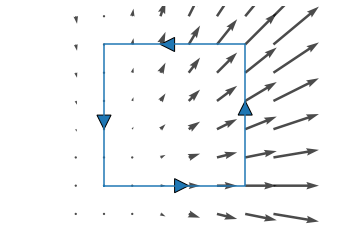

In [ ]:
#@title Integral de línea { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1)
ax.plot([0,1,1,0,0], [0,0,1,1,0])
ax.arrow(1, 0.5, 0, 0.1, head_length=.1, head_width=.1, length_includes_head=True)
ax.arrow(0.5, 1, -0.1, 0, head_length=.1, head_width=.1, length_includes_head=True)
ax.arrow(0, 0.5, 0, -0.1, head_length=.1, head_width=.1, length_includes_head=True)
ax.arrow(0.5, 0, 0.1, 0, head_length=.1, head_width=.1, length_includes_head=True)
X, Y = np.meshgrid(np.linspace(-0.2,1.2,8),np.linspace(-0.2,1.2,8))
U = X**2
V = X*Y
ax.quiver(X,Y,U,V,alpha=0.7)
ax.axis('equal')
ax.axis('off');
#plt.savefig('ejm_intlinea.pdf')


Por lo tanto, para $F(x) = (x_1^2, x_1 x_2)$,
\begin{align*}
\int_{\mathcal{C}} x_1^2 dx_1 + x_1 x_2 dx_2
&= \sum_{i=1}^4 \int_{\mathcal{C}_i} F_1(x) dx_1 + F_2(x) dx_2 \\
&= \sum_{i=1}^4 \int_0^1 \langle F(\gamma_i(t)), \gamma_i'(t) \rangle dt \\
&= \int_0^1 t^2 dt + \int_0^1 t dt + \int_0^1 -(1-t)^2 dt + \int_0^1 0 dt \\
&= \frac{1}{3} + \frac{1}{2} - \frac{1}{3} = \frac{1}{2}.
\end{align*}

---